In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")
 
# NLP / EDA
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from langdetect import detect, LangDetectException
import emoji

In [2]:
# Plotting theme 
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
PALETTE = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71", "#2980B9"]

In [3]:
# 1. Load data 
df = pd.read_excel("dataset.xlsx")
print(f"Shape: {df.shape}")
print('datatypes:\n',df.dtypes)
df.head(3)

Shape: (1440, 3)
datatypes:
 title     object
rating     int64
body      object
dtype: object


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."


In [4]:
# 2. Basic cleaning
df["title"] = df["title"].astype(str).str.strip()
df["body"]  = df["body"].astype(str).str.strip()
df["text"]  = df["title"] + " " + df["body"]   # combined text field

In [5]:
# Detect language per row (best-effort; fallback = 'en')
def safe_detect(t):
    try:
        return detect(t)
    except LangDetectException:
        return "unknown"
 
df["lang"] = df["text"].apply(safe_detect)
print("\nLanguage distribution:\n", df["lang"].value_counts())


Language distribution:
 lang
en    1414
hi      11
ca       3
id       3
af       2
it       1
ml       1
lv       1
et       1
de       1
so       1
no       1
Name: count, dtype: int64


In [6]:
# Flag emojis
df["has_emoji"] = df["text"].apply(lambda t: bool(emoji.emoji_count(t)))

In [7]:
# Strip emojis & non-ASCII for NLP steps that need clean ASCII
def clean_text(t):
    t = emoji.replace_emoji(t, replace="")     # remove emoji
    t = re.sub(r"[^\x00-\x7F]+", " ", t)       # remove non-ASCII (Hindi/Malayalam)
    t = re.sub(r"[^a-zA-Z\s]", " ", t)         # keep letters only
    t = re.sub(r"\s+", " ", t).strip().lower()
    return t
 
df["clean"] = df["text"].apply(clean_text)
print("\nSample cleaned:\n", df["clean"].head(3).tolist())


Sample cleaned:
 ['horrible product very disappointed with the overall performance from samsung', 'camera quality is not like megapixel camera quality is low', 'overall got the mobile on the launch date battery must be appreciatedcamera is just averagemobile performance is above average hz refresh rate if u r buying the mobile for this feature then i m afraid u may get disappointed it s just normal the usb cable is too small in lengthit s a good mobile in this budget there are no returns for this only replacement is available hence choose wisely before buying']


In [8]:
# 3. Label encoding (for models, stored here for convenience)
# Map rating → sentiment bucket
df["sentiment"] = df["rating"].map({1: "negative", 2: "negative",
                                     3: "neutral",
                                     4: "positive", 5: "positive"})
df["label"] = df["sentiment"].map({"negative": 0, "neutral": 1, "positive": 2})

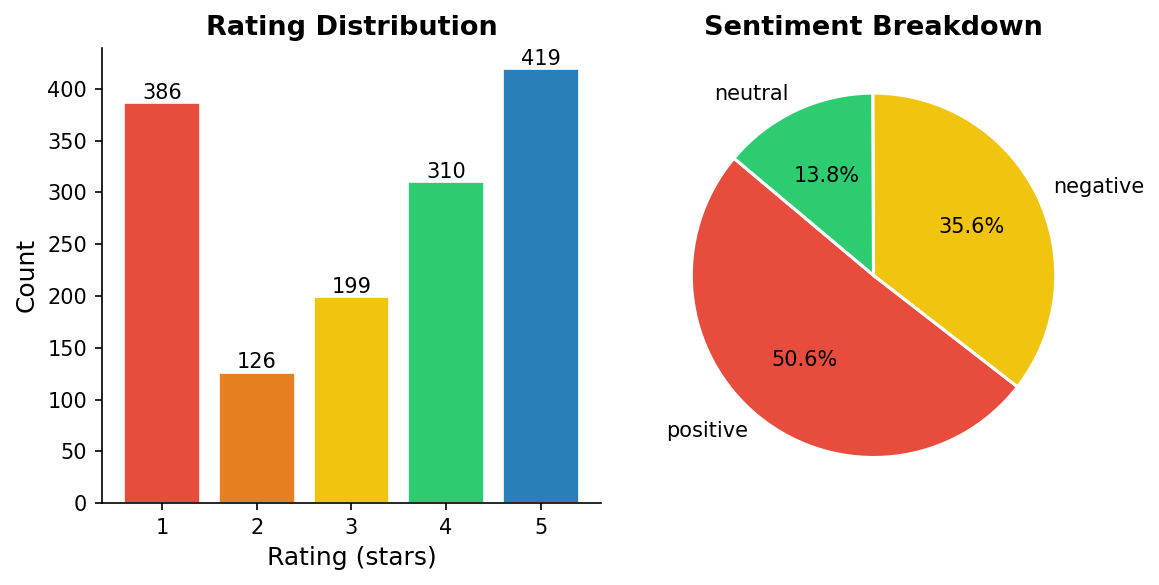

In [9]:
# 4. Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
 
counts = df["rating"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Rating (stars)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Rating Distribution", fontsize=13, fontweight="bold")
for i, v in enumerate(counts.values):
    axes[0].text(counts.index[i], v + 4, str(v), ha="center", fontsize=10)

sent_counts = df["sentiment"].value_counts()
wedge_colors = ["#E74C3C", "#F1C40F", "#2ECC71"]
axes[1].pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Sentiment Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

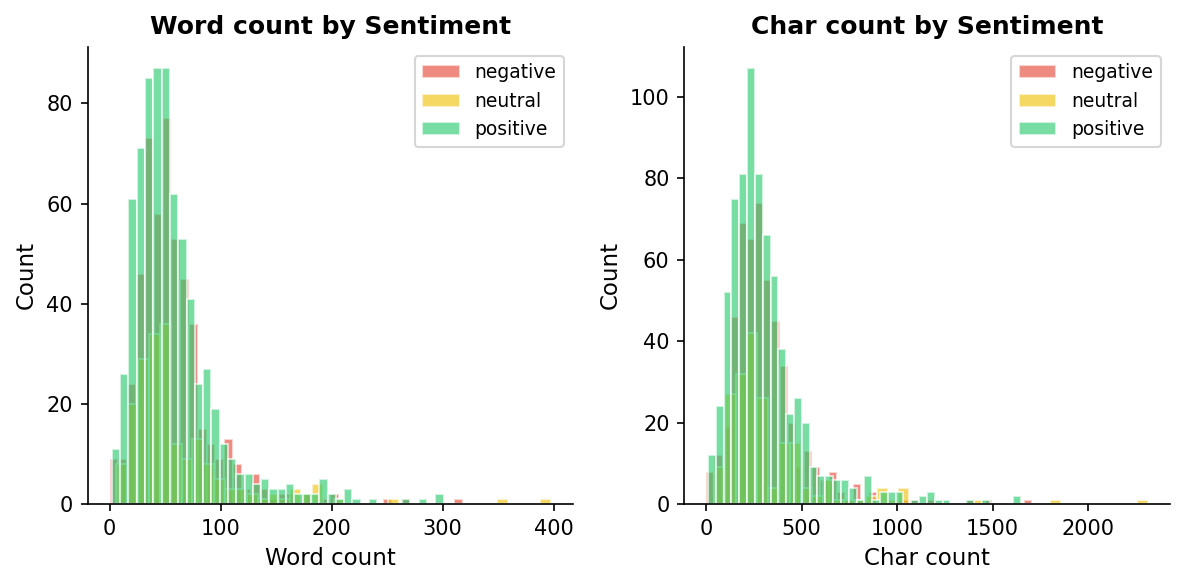

In [10]:
# ── 5. Text length analysis
df["word_count"]  = df["clean"].str.split().apply(len)
df["char_count"]  = df["clean"].str.len()
 
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col, label in zip(axes,
                           ["word_count", "char_count"],
                           ["Word count", "Char count"]):
    for sent, color in zip(["negative", "neutral", "positive"],
                            ["#E74C3C", "#F1C40F", "#2ECC71"]):
        subset = df[df["sentiment"] == sent][col]
        ax.hist(subset, bins=40, alpha=0.65, label=sent, color=color, edgecolor="white")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{label} by Sentiment", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# ── 6. VADER Sentiment Analysis ──────────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()
 
def vader_scores(t):
    s = analyzer.polarity_scores(t)
    return pd.Series([s["neg"], s["neu"], s["pos"], s["compound"]],
                     index=["vader_neg", "vader_neu", "vader_pos", "vader_compound"])
 
vader_df = df["clean"].apply(vader_scores)
df = pd.concat([df, vader_df], axis=1)

In [12]:
# VADER predicted label
def vader_label(compound):
    if compound >= 0.05:  return "positive"
    elif compound <= -0.05: return "negative"
    else:                   return "neutral"
 
df["vader_sentiment"] = df["vader_compound"].apply(vader_label)

In [13]:
# Agreement with rating-based label
agreement = (df["vader_sentiment"] == df["sentiment"]).mean()
print(f"\nVADER ↔ Rating agreement: {agreement:.1%}")


VADER ↔ Rating agreement: 73.1%


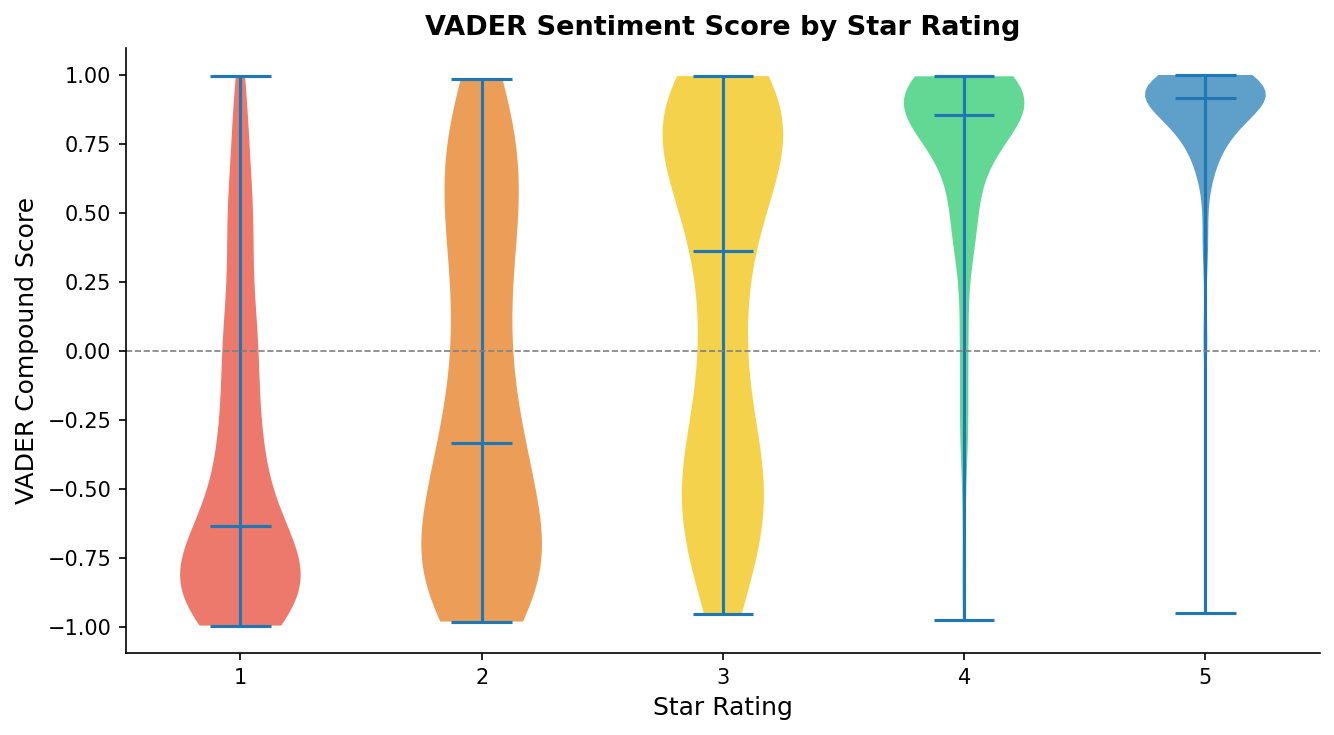

In [14]:
# Violin: VADER compound by star rating
fig, ax = plt.subplots(figsize=(9, 5))
data_by_rating = [df[df["rating"] == r]["vader_compound"].values for r in range(1, 6)]
parts = ax.violinplot(data_by_rating, positions=range(1, 6), showmedians=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.75)
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("VADER Compound Score", fontsize=12)
ax.set_title("VADER Sentiment Score by Star Rating", fontsize=13, fontweight="bold")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

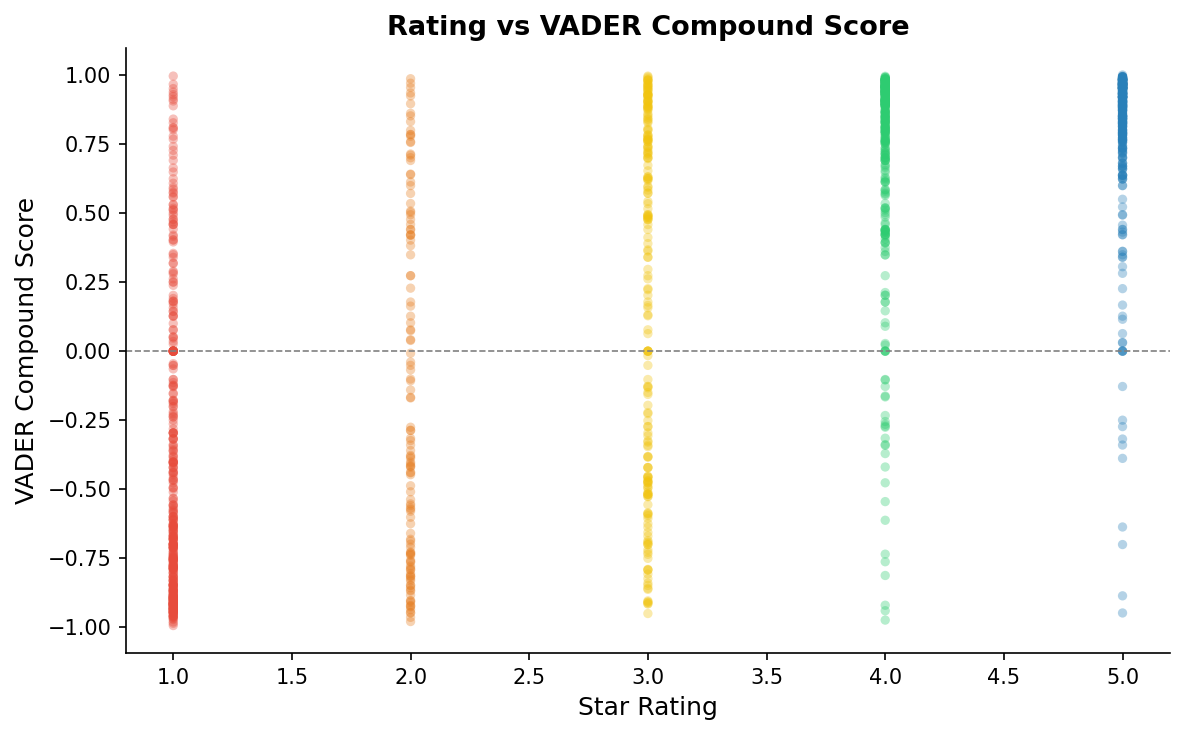

In [15]:
# Scatter: VADER compound vs rating
fig, ax = plt.subplots(figsize=(8, 5))
scatter_colors = df["rating"].map({1: "#E74C3C", 2: "#E67E22",
                                    3: "#F1C40F", 4: "#2ECC71", 5: "#2980B9"})
ax.scatter(df["rating"], df["vader_compound"],
           c=scatter_colors, alpha=0.35, s=20, edgecolors="none")
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("VADER Compound Score", fontsize=12)
ax.set_title("Rating vs VADER Compound Score", fontsize=13, fontweight="bold")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

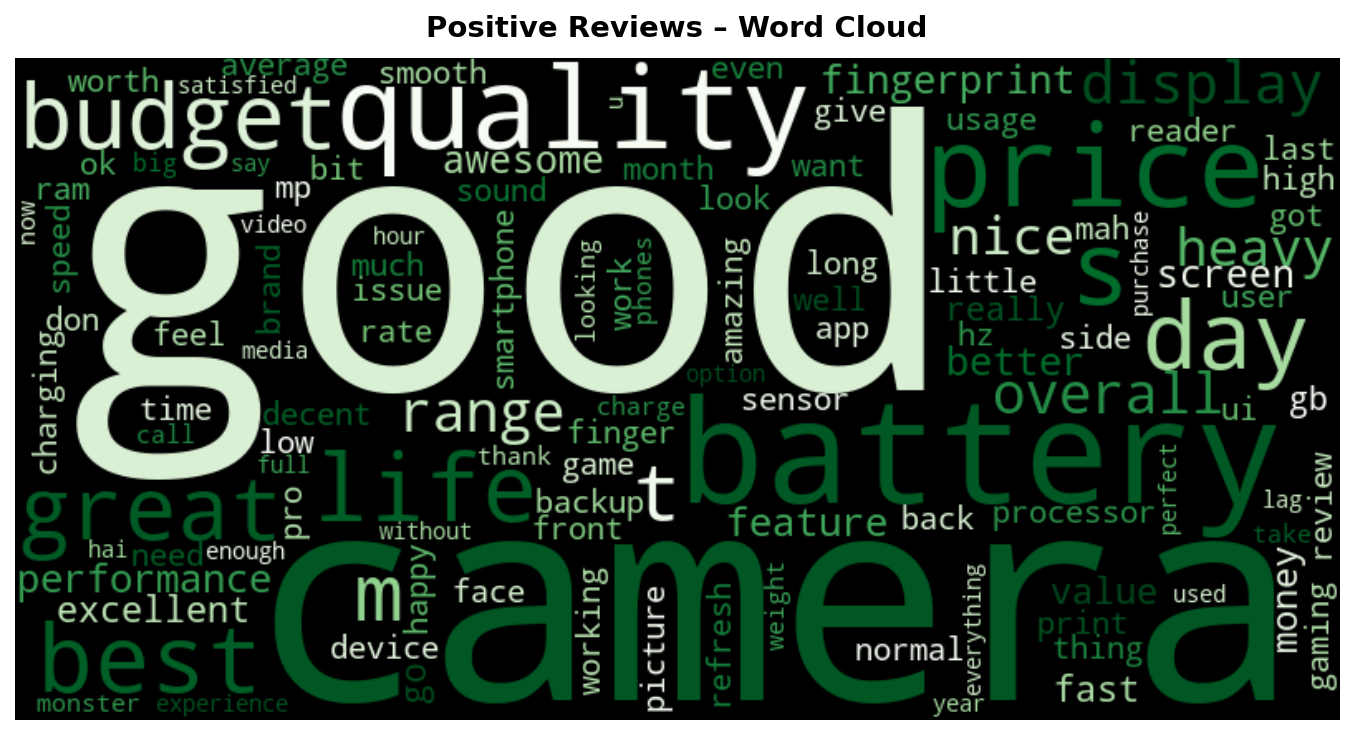

Saved → wc_positive.png


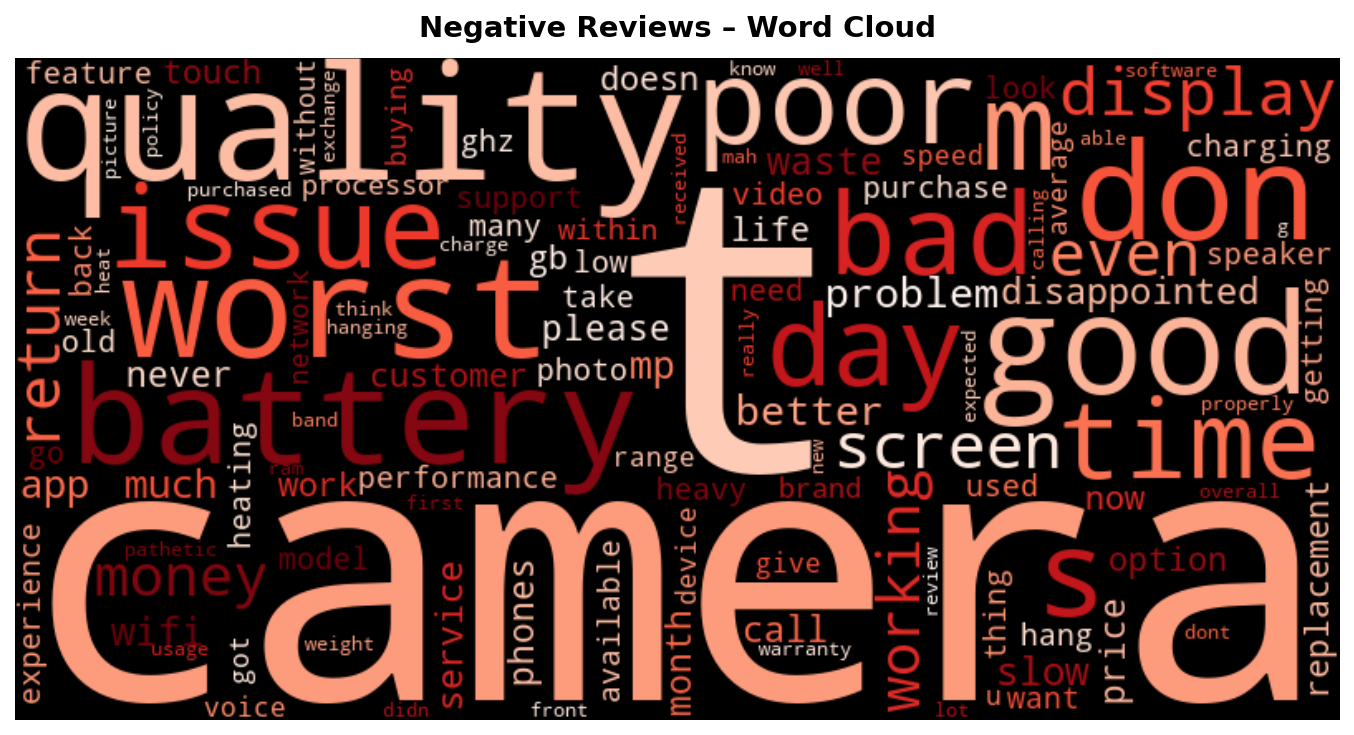

Saved → wc_negative.png


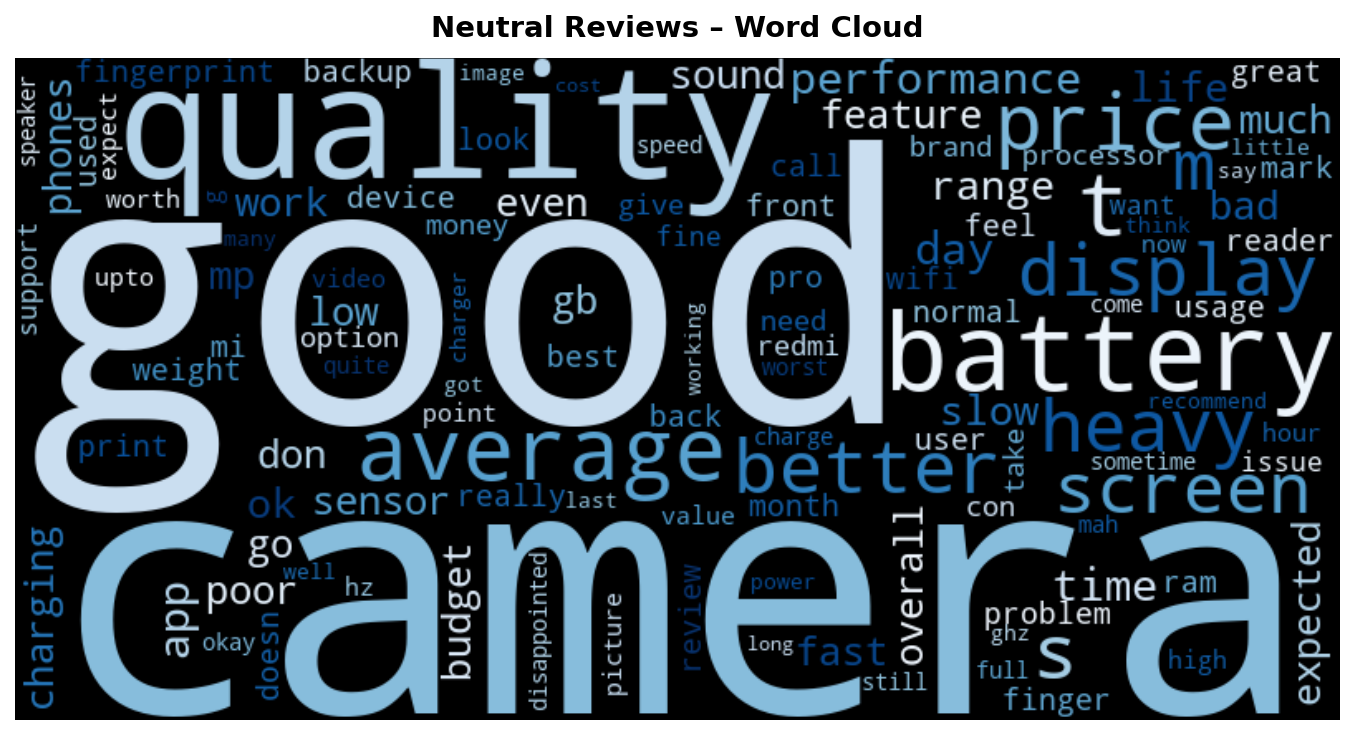

Saved → wc_neutral.png


In [16]:
# 7. Word Clouds
stopwords = set(STOPWORDS) | {"phone", "mobile", "samsung", "galaxy",
                               "amazon", "product", "one", "also", "will",
                               "buy", "bought", "use", "using"}
 
def make_wordcloud(text_series, title, filename, colormap):
    text = " ".join(text_series)
    wc = WordCloud(
        width=800, height=400,
        background_color="black",
        stopwords=stopwords,
        colormap=colormap,
        max_words=120,
        collocations=False,
    ).generate(text)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()
    print(f"Saved → {filename}")
 
make_wordcloud(df[df["sentiment"]=="positive"]["clean"], "Positive Reviews – Word Cloud", "wc_positive.png", "Greens")
make_wordcloud(df[df["sentiment"]=="negative"]["clean"], "Negative Reviews – Word Cloud", "wc_negative.png", "Reds")
make_wordcloud(df[df["sentiment"]=="neutral"]["clean"],  "Neutral Reviews – Word Cloud",  "wc_neutral.png",  "Blues")

In [17]:
# ── 8. TF-IDF Top Terms per Sentiment ───────────────────────────────────────
def top_tfidf_terms(corpus, n=20):
    vec = TfidfVectorizer(max_features=5000, stop_words="english",
                          ngram_range=(1, 2), min_df=2)
    X = vec.fit_transform(corpus)
    scores = np.asarray(X.mean(axis=0)).flatten()
    terms  = vec.get_feature_names_out()
    top_idx = scores.argsort()[::-1][:n]
    return [(terms[i], scores[i]) for i in top_idx]
 
sentiments = ["positive", "negative", "neutral"]
colors_map  = {"positive": "#2ECC71", "negative": "#E74C3C", "neutral": "#3498DB"}

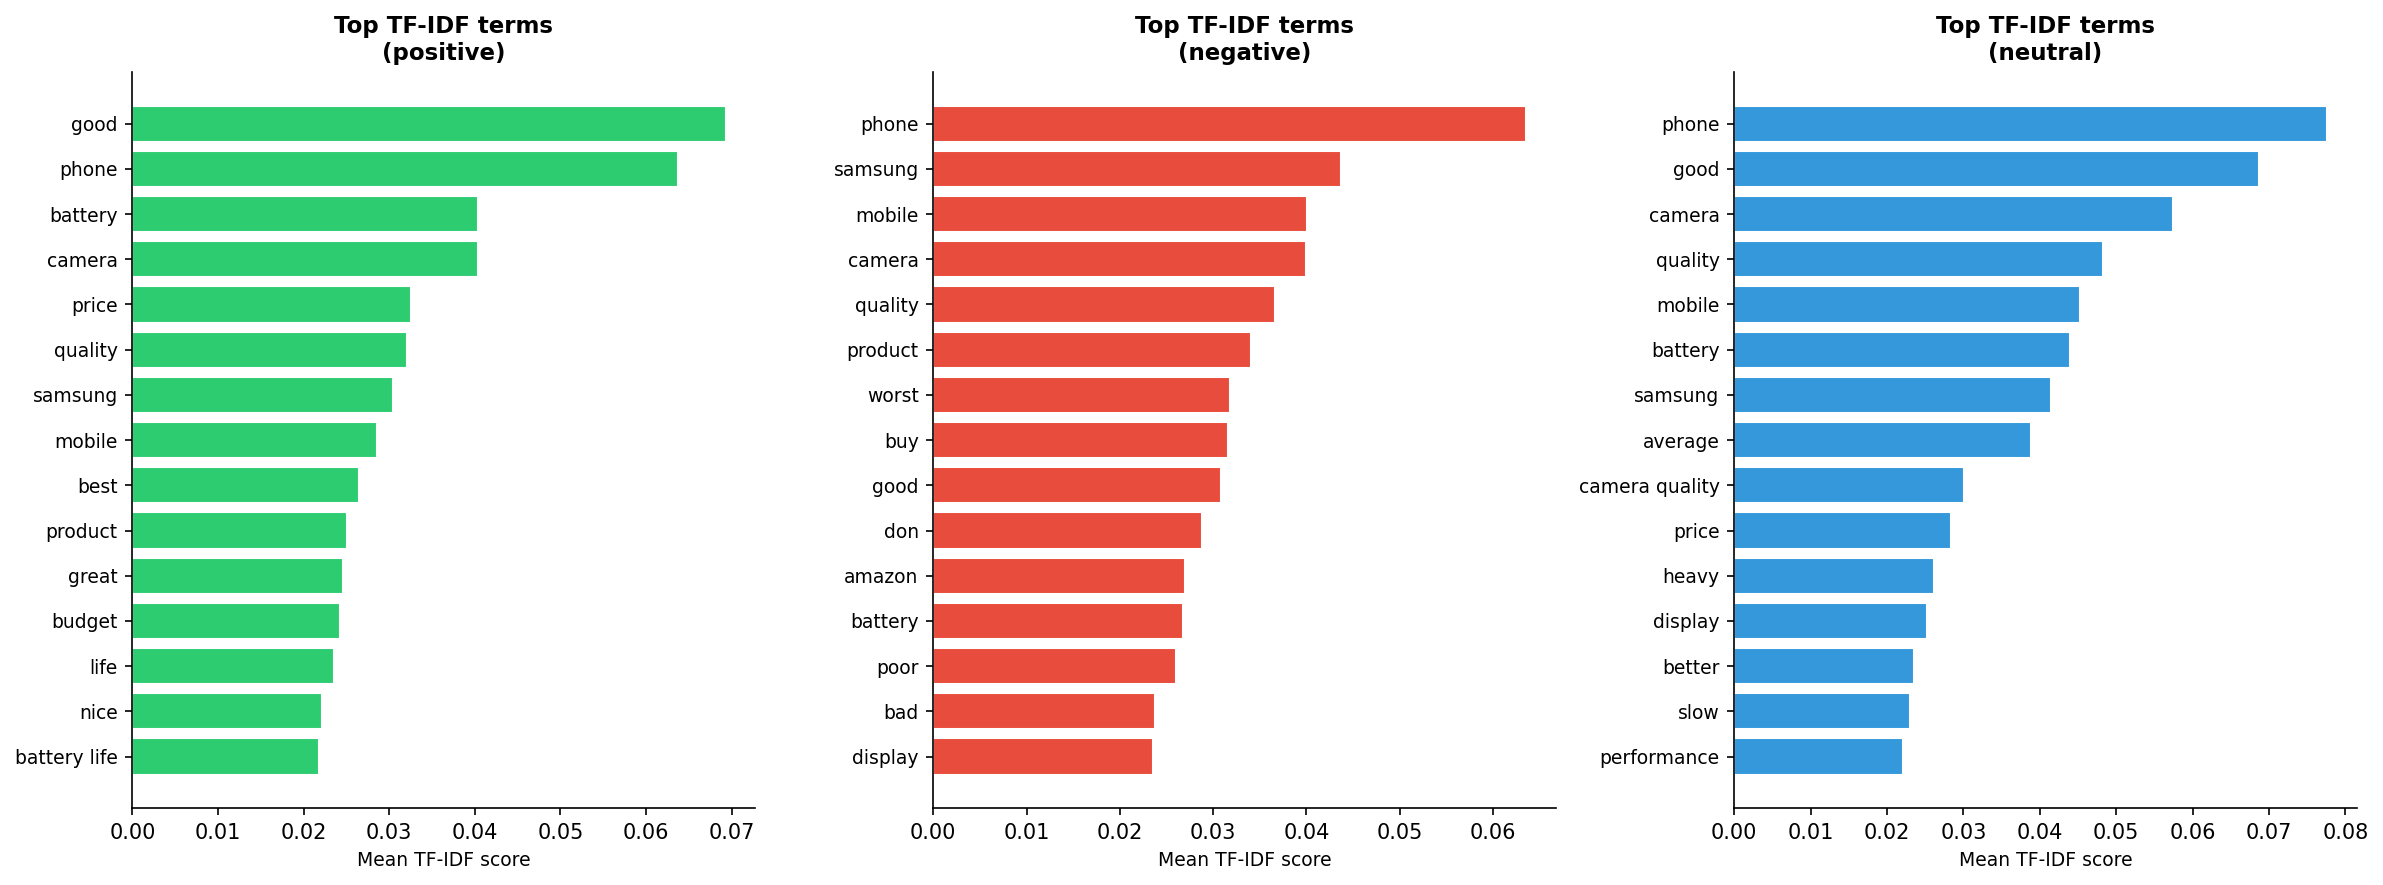

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, sent in zip(axes, sentiments):
    corpus = df[df["sentiment"] == sent]["clean"].tolist()
    top = top_tfidf_terms(corpus, n=15)
    terms, scores = zip(*top)
    ax.barh(range(len(terms)), scores, color=colors_map[sent], edgecolor="white")
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"Top TF-IDF terms\n({sent})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean TF-IDF score", fontsize=9)
plt.tight_layout()
plt.show()

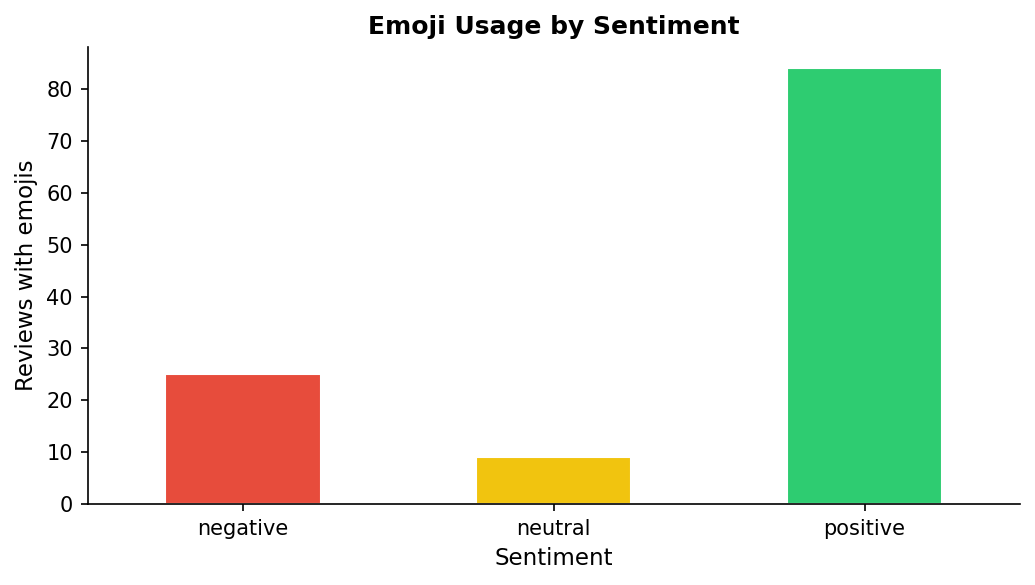

In [19]:
# ── 9. Emoji analysis ────────────────────────────────────────────────────────
emoji_counts = df[df["has_emoji"]].groupby("sentiment")["has_emoji"].count()
fig, ax = plt.subplots(figsize=(7, 4))
emoji_counts.plot(kind="bar", ax=ax,
                  color=["#E74C3C", "#F1C40F", "#2ECC71"],
                  edgecolor="white")
ax.set_xlabel("Sentiment", fontsize=11)
ax.set_ylabel("Reviews with emojis", fontsize=11)
ax.set_title("Emoji Usage by Sentiment", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

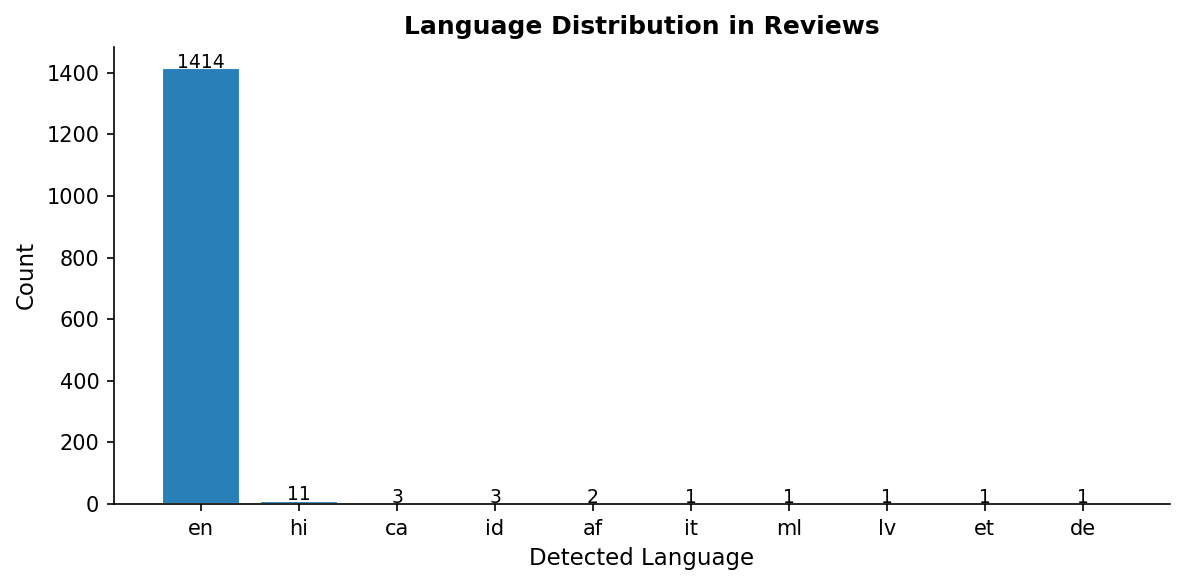

In [20]:
# ── 10. Language distribution ────────────────────────────────────────────────
lang_counts = df["lang"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lang_counts.index, lang_counts.values, color="#2980B9", edgecolor="white")
ax.set_xlabel("Detected Language", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Language Distribution in Reviews", fontsize=12, fontweight="bold")
for i, v in enumerate(lang_counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

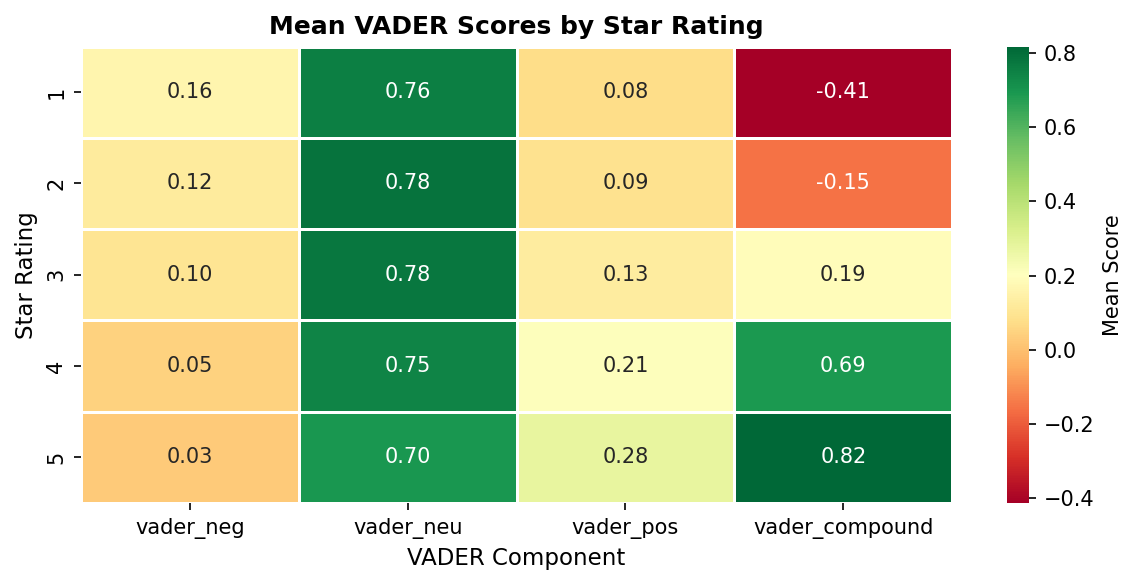

In [21]:
# ── 11. Heatmap: avg VADER scores by rating ──────────────────────────────────
heat_data = df.groupby("rating")[["vader_neg","vader_neu","vader_pos","vader_compound"]].mean()
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Mean Score"})
ax.set_title("Mean VADER Scores by Star Rating", fontsize=12, fontweight="bold")
ax.set_xlabel("VADER Component", fontsize=11)
ax.set_ylabel("Star Rating", fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
df.to_csv("cleaned_reviews.csv", index=False)
print(df.columns.tolist())
print("\nCleaned data saved → cleaned_reviews.csv")

['title', 'rating', 'body', 'text', 'lang', 'has_emoji', 'clean', 'sentiment', 'label', 'word_count', 'char_count', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_sentiment']

Cleaned data saved → cleaned_reviews.csv


In [23]:
# ── 12. EDA Summary stats ────────────────────────────────────────────────────
print("\n══ EDA Summary ══")
print(f"Total reviews        : {len(df)}")
print(f"Positive (4-5)      : {(df.sentiment=='positive').sum()} ({(df.sentiment=='positive').mean():.1%})")
print(f"Neutral  (3)        : {(df.sentiment=='neutral').sum()} ({(df.sentiment=='neutral').mean():.1%})")
print(f"Negative (1-2)      : {(df.sentiment=='negative').sum()} ({(df.sentiment=='negative').mean():.1%})")
print(f"Avg word count       : {df.word_count.mean():.1f}")
print(f"Reviews with emojis  : {df.has_emoji.sum()}")
print(f"Non-English reviews  : {(df.lang != 'en').sum()}")
print(f"VADER–Rating agree   : {agreement:.1%}")


══ EDA Summary ══
Total reviews        : 1440
Positive (4-5)      : 729 (50.6%)
Neutral  (3)        : 199 (13.8%)
Negative (1-2)      : 512 (35.6%)
Avg word count       : 58.6
Reviews with emojis  : 118
Non-English reviews  : 26
VADER–Rating agree   : 73.1%
